In [1]:
#import dask.dataframe as dd
import pandas as pd
from sklearn.preprocessing import StandardScaler,OneHotEncoder
df = pd.read_csv("/Users/hamzatriki/3ºProyectoDeDatos2/PD2/data/ex1/eventos_espera_semana_hp.csv", delimiter=",")
df

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,holding_point,parado,runway,fecha_despegue,hora_despegue
0,39bdae,2024-12-07 10:01:23.317,2024-12-07 10:02:45.266,2024-12-07 10:02:46.296,82.979,Medium 2 (between 34000 kg to 136000 kg),-3.561209,40.499423,-3.559227,40.506278,Y1,False,18L/36R,2024-12-07,10
1,4d24f1,2024-12-01 16:33:52.843,2024-12-01 16:35:40.634,2024-12-01 16:35:43.103,110.260,Medium 2 (between 34000 kg to 136000 kg),-3.576221,40.491579,-3.574645,40.497584,Z2,False,18R/36L,2024-12-01,16
2,71c082,2024-12-07 20:53:30.784,2024-12-07 20:55:13.042,2024-12-07 20:55:13.148,102.364,Heavy (larger than 136000 kg),-3.576253,40.491532,-3.574631,40.496567,Z2,False,18R/36L,2024-12-07,20
3,06a140,2024-12-01 18:26:29.008,2024-12-01 18:27:27.916,2024-12-01 18:27:29.141,60.133,Heavy (larger than 136000 kg),-3.561240,40.499423,-3.559211,40.505358,Y1,False,18L/36R,2024-12-01,18
4,06a140,2024-12-02 16:23:27.259,2024-12-02 16:24:41.134,2024-12-02 16:24:43.186,75.927,Heavy (larger than 136000 kg),-3.561234,40.499428,-3.559196,40.504543,Y1,False,18L/36R,2024-12-02,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4000,347307,2024-12-07 14:38:54.942,2024-12-07 14:41:46.659,2024-12-07 14:41:47.136,172.194,Medium 2 (between 34000 kg to 136000 kg),-3.561203,40.499565,-3.559235,40.505859,Y1,True,18L/36R,2024-12-07,14
4001,4bb289,2024-12-01 14:12:43.985,2024-12-01 14:14:08.288,2024-12-01 14:14:08.764,84.779,Medium 2 (between 34000 kg to 136000 kg),-3.561225,40.499481,-3.559235,40.505894,Y1,False,18L/36R,2024-12-01,14
4002,4cae17,2024-12-02 05:03:38.741,2024-12-02 05:04:47.780,2024-12-02 05:04:48.984,70.243,Medium 2 (between 34000 kg to 136000 kg),-3.576253,40.491521,-3.574661,40.498764,Z2,False,18R/36L,2024-12-02,5
4003,4cae17,2024-12-06 11:07:15.791,2024-12-06 11:08:21.696,2024-12-06 11:08:22.179,66.388,Medium 2 (between 34000 kg to 136000 kg),-3.561218,40.501179,-3.559227,40.507418,Y3,False,18L/36R,2024-12-06,11


In [2]:
df["holding_point"].unique()

array(['Y1', 'Z2', 'Z4', 'Y2', 'K2', 'Z3', 'Z1', 'LA', 'LF', 'Y3', 'LC',
       'L1', 'K3', 'KA6', 'LE', 'KA8', 'LD', 'LB', 'K1', 'Z6'],
      dtype=object)

In [3]:
df.columns

Index(['ICAO', 'llegada_punto', 'salida_punto', 'despegue', 'tiempo_espera',
       'aircraft_type', 'llegada_lon', 'llegada_lat', 'salida_lon',
       'salida_lat', 'holding_point', 'parado', 'runway', 'fecha_despegue',
       'hora_despegue'],
      dtype='object')

In [4]:
df = df.dropna().reset_index(drop=True)

In [5]:
df["holding_point"].unique()

array(['Y1', 'Z2', 'Z4', 'Y2', 'K2', 'Z3', 'Z1', 'LA', 'LF', 'Y3', 'LC',
       'L1', 'K3', 'KA6', 'LE', 'KA8', 'LB', 'K1', 'Z6'], dtype=object)

In [6]:
df.dtypes

ICAO               object
llegada_punto      object
salida_punto       object
despegue           object
tiempo_espera     float64
aircraft_type      object
llegada_lon       float64
llegada_lat       float64
salida_lon        float64
salida_lat        float64
holding_point      object
parado               bool
runway             object
fecha_despegue     object
hora_despegue       int64
dtype: object

In [7]:
icaos = df[["ICAO","tiempo_espera"]]
df.head()

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,holding_point,parado,runway,fecha_despegue,hora_despegue
0,39bdae,2024-12-07 10:01:23.317,2024-12-07 10:02:45.266,2024-12-07 10:02:46.296,82.979,Medium 2 (between 34000 kg to 136000 kg),-3.561209,40.499423,-3.559227,40.506278,Y1,False,18L/36R,2024-12-07,10
1,4d24f1,2024-12-01 16:33:52.843,2024-12-01 16:35:40.634,2024-12-01 16:35:43.103,110.260,Medium 2 (between 34000 kg to 136000 kg),-3.576221,40.491579,-3.574645,40.497584,Z2,False,18R/36L,2024-12-01,16
2,71c082,2024-12-07 20:53:30.784,2024-12-07 20:55:13.042,2024-12-07 20:55:13.148,102.364,Heavy (larger than 136000 kg),-3.576253,40.491532,-3.574631,40.496567,Z2,False,18R/36L,2024-12-07,20
3,06a140,2024-12-01 18:26:29.008,2024-12-01 18:27:27.916,2024-12-01 18:27:29.141,60.133,Heavy (larger than 136000 kg),-3.561240,40.499423,-3.559211,40.505358,Y1,False,18L/36R,2024-12-01,18
4,06a140,2024-12-02 16:23:27.259,2024-12-02 16:24:41.134,2024-12-02 16:24:43.186,75.927,Heavy (larger than 136000 kg),-3.561234,40.499428,-3.559196,40.504543,Y1,False,18L/36R,2024-12-02,16


In [8]:
## Cargar bien los tiempos
timestap_columns = ["llegada_punto","salida_punto","despegue"]
for col in timestap_columns:
    df[col] = pd.to_datetime(df[col],format="%Y-%m-%d %H:%M:%S.%f")
df["fecha_despegue"] = pd.to_datetime(df["fecha_despegue"],format="%Y-%m-%d")
df.dtypes

ICAO                      object
llegada_punto     datetime64[ns]
salida_punto      datetime64[ns]
despegue          datetime64[ns]
tiempo_espera            float64
aircraft_type             object
llegada_lon              float64
llegada_lat              float64
salida_lon               float64
salida_lat               float64
holding_point             object
parado                      bool
runway                    object
fecha_despegue    datetime64[ns]
hora_despegue              int64
dtype: object

In [9]:
df.sort_values("despegue")

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,holding_point,parado,runway,fecha_despegue,hora_despegue
1967,aac33e,2024-12-01 00:36:58.063,2024-12-01 00:39:47.434,2024-12-01 00:39:48.750,170.687,Heavy (larger than 136000 kg),-3.572554,40.490578,-3.574645,40.497735,Z1,True,18R/36L,2024-12-01,0
2354,347604,2024-12-01 00:49:59.888,2024-12-01 00:50:51.492,2024-12-01 00:50:51.998,52.110,Heavy (larger than 136000 kg),-3.576221,40.491532,-3.574630,40.498434,Z2,False,18R/36L,2024-12-01,0
1689,896614,2024-12-01 02:56:52.255,2024-12-01 02:59:23.321,2024-12-01 02:59:25.243,152.988,Heavy (larger than 136000 kg),-3.576237,40.491497,-3.574630,40.495547,Z2,False,18R/36L,2024-12-01,2
3901,34134e,2024-12-01 04:18:23.081,2024-12-01 04:20:28.852,2024-12-01 04:20:29.259,126.178,Medium 2 (between 34000 kg to 136000 kg),-3.576599,40.492481,-3.574645,40.498515,Z4,False,18R/36L,2024-12-01,4
1362,4cada6,2024-12-01 04:58:11.239,2024-12-01 05:00:55.900,2024-12-01 05:00:56.920,165.681,Medium 2 (between 34000 kg to 136000 kg),-3.576456,40.491742,-3.574645,40.498247,Z2,True,18R/36L,2024-12-01,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
771,346456,2024-12-07 23:31:52.062,2024-12-07 23:33:19.151,2024-12-07 23:33:19.353,87.291,Heavy (larger than 136000 kg),-3.572632,40.491835,-3.574631,40.497631,Z3,False,18R/36L,2024-12-07,23
1323,346057,2024-12-07 23:40:44.612,2024-12-07 23:44:31.084,2024-12-07 23:44:31.284,226.672,Heavy (larger than 136000 kg),-3.572617,40.491835,-3.574646,40.498306,Z3,False,18R/36L,2024-12-07,23
3195,346310,2024-12-07 23:44:29.668,2024-12-07 23:47:32.440,2024-12-07 23:47:33.248,183.580,Heavy (larger than 136000 kg),-3.576248,40.491508,-3.574661,40.498318,Z2,False,18R/36L,2024-12-07,23
2506,aace63,2024-12-07 23:48:35.885,2024-12-07 23:50:02.452,2024-12-07 23:50:03.161,87.276,Heavy (larger than 136000 kg),-3.572617,40.491840,-3.574646,40.497265,Z3,False,18R/36L,2024-12-07,23


In [10]:
df.groupby("fecha_despegue")["ICAO"]

In [11]:
categorical_columns = df.select_dtypes("object")
categorical_columns.columns.drop(["ICAO","holding_point"])

Index(['aircraft_type', 'runway'], dtype='object')

In [12]:
categorical_columns

,ICAO,aircraft_type,holding_point,runway
0,39bdae,Medium 2 (between 34000 kg to 136000 kg),Y1,18L/36R
1,4d24f1,Medium 2 (between 34000 kg to 136000 kg),Z2,18R/36L
2,71c082,Heavy (larger than 136000 kg),Z2,18R/36L
3,06a140,Heavy (larger than 136000 kg),Y1,18L/36R
4,06a140,Heavy (larger than 136000 kg),Y1,18L/36R
...,...,...,...,...
3970,347307,Medium 2 (between 34000 kg to 136000 kg),Y1,18L/36R
3971,4bb289,Medium 2 (between 34000 kg to 136000 kg),Y1,18L/36R
3972,4cae17,Medium 2 (between 34000 kg to 136000 kg),Z2,18R/36L
3973,4cae17,Medium 2 (between 34000 kg to 136000 kg),Y3,18L/36R


In [15]:
categorical_columns

Index(['aircraft_type', 'holding_point', 'runway'], dtype='object')

In [14]:
encoder = OneHotEncoder(sparse_output=False)

categorical_columns = df.select_dtypes("object").columns.drop(["ICAO"])

encoded_data = encoder.fit_transform(df[categorical_columns])

df_encoded = pd.DataFrame(encoded_data, columns = encoder.get_feature_names_out())
df = df.drop(columns = ["aircraft_type","runway"])
df_encoded = pd.concat([df,df_encoded],axis = 1)

In [13]:
encoder = OneHotEncoder(sparse_output=False)

categorical_columns = df.select_dtypes("object").columns.drop(["ICAO","holding_point"])

encoded_data = encoder.fit_transform(df[categorical_columns])

df_encoded = pd.DataFrame(encoded_data, columns = encoder.get_feature_names_out())
df = df.drop(columns = categorical_columns)
df_encoded = pd.concat([df,df_encoded],axis = 1)

In [14]:
def calcular_tiempo_relativo(tiempo_referencia,tiempo_fila):
    tiempo_referencia_segundos = tiempo_referencia.timestamp()
    tiempo_fila_segundos = tiempo_fila.timestamp()
    return (tiempo_referencia_segundos - tiempo_fila_segundos)

In [16]:
df_encoded_sorted = df_encoded.sort_values("despegue",ascending = False).reset_index()
df_encoded_sorted

,index,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,llegada_lon,llegada_lat,salida_lon,salida_lat,...,holding_point_Y3,holding_point_Z1,holding_point_Z2,holding_point_Z3,holding_point_Z4,holding_point_Z6,runway_14L/32R,runway_14R/32L,runway_18L/36R,runway_18R/36L
0,1176,4cae92,2024-12-07 23:55:17.776,2024-12-07 23:57:08.891,2024-12-07 23:57:09.599,111.823,-3.576248,40.491508,-3.574645,40.497735,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2506,aace63,2024-12-07 23:48:35.885,2024-12-07 23:50:02.452,2024-12-07 23:50:03.161,87.276,-3.572617,40.491840,-3.574646,40.497265,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,3195,346310,2024-12-07 23:44:29.668,2024-12-07 23:47:32.440,2024-12-07 23:47:33.248,183.580,-3.576248,40.491508,-3.574661,40.498318,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1323,346057,2024-12-07 23:40:44.612,2024-12-07 23:44:31.084,2024-12-07 23:44:31.284,226.672,-3.572617,40.491835,-3.574646,40.498306,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,771,346456,2024-12-07 23:31:52.062,2024-12-07 23:33:19.151,2024-12-07 23:33:19.353,87.291,-3.572632,40.491835,-3.574631,40.497631,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3970,1362,4cada6,2024-12-01 04:58:11.239,2024-12-01 05:00:55.900,2024-12-01 05:00:56.920,165.681,-3.576456,40.491742,-3.574645,40.498247,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3971,3901,34134e,2024-12-01 04:18:23.081,2024-12-01 04:20:28.852,2024-12-01 04:20:29.259,126.178,-3.576599,40.492481,-3.574645,40.498515,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3972,1689,896614,2024-12-01 02:56:52.255,2024-12-01 02:59:23.321,2024-12-01 02:59:25.243,152.988,-3.576237,40.491497,-3.574630,40.495547,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3973,2354,347604,2024-12-01 00:49:59.888,2024-12-01 00:50:51.492,2024-12-01 00:50:51.998,52.110,-3.576221,40.491532,-3.574630,40.498434,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


{'whiskers': [<matplotlib.lines.Line2D at 0x140eaa300>,
 'caps': [<matplotlib.lines.Line2D at 0x140eaa9f0>,
 'boxes': [<matplotlib.lines.Line2D at 0x140809940>],
 'medians': [<matplotlib.lines.Line2D at 0x140eab050>],
 'fliers': [<matplotlib.lines.Line2D at 0x140eab380>],
 'means': []}

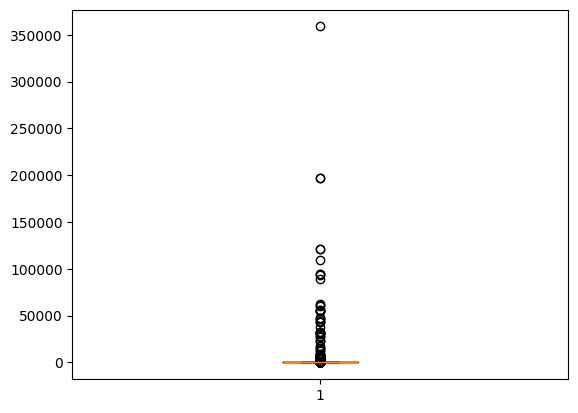

In [17]:
import matplotlib.pyplot as plt

plt.boxplot(df_encoded_sorted["tiempo_espera"])

In [18]:
Q1 = df_encoded_sorted['tiempo_espera'].quantile(0.25)  # Primer cuartil
Q3 = df_encoded_sorted['tiempo_espera'].quantile(0.75)  # Tercer cuartil
IQR = Q3 - Q1  # Rango intercuartílico

# Definir límites para detectar outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtrar valores dentro de los límites
df_sin_outliers = df_encoded_sorted[(df_encoded_sorted['tiempo_espera'] >= limite_inferior) & (df_encoded_sorted['tiempo_espera'] <= limite_superior)]

print("DataFrame sin outliers:")
df_sin_outliers.head()

DataFrame sin outliers:


,index,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,llegada_lon,llegada_lat,salida_lon,salida_lat,...,holding_point_Y3,holding_point_Z1,holding_point_Z2,holding_point_Z3,holding_point_Z4,holding_point_Z6,runway_14L/32R,runway_14R/32L,runway_18L/36R,runway_18R/36L
0,1176,4cae92,2024-12-07 23:55:17.776,2024-12-07 23:57:08.891,2024-12-07 23:57:09.599,111.823,-3.576248,40.491508,-3.574645,40.497735,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2506,aace63,2024-12-07 23:48:35.885,2024-12-07 23:50:02.452,2024-12-07 23:50:03.161,87.276,-3.572617,40.491840,-3.574646,40.497265,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,3195,346310,2024-12-07 23:44:29.668,2024-12-07 23:47:32.440,2024-12-07 23:47:33.248,183.580,-3.576248,40.491508,-3.574661,40.498318,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1323,346057,2024-12-07 23:40:44.612,2024-12-07 23:44:31.084,2024-12-07 23:44:31.284,226.672,-3.572617,40.491835,-3.574646,40.498306,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,771,346456,2024-12-07 23:31:52.062,2024-12-07 23:33:19.151,2024-12-07 23:33:19.353,87.291,-3.572632,40.491835,-3.574631,40.497631,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


<Axes: >

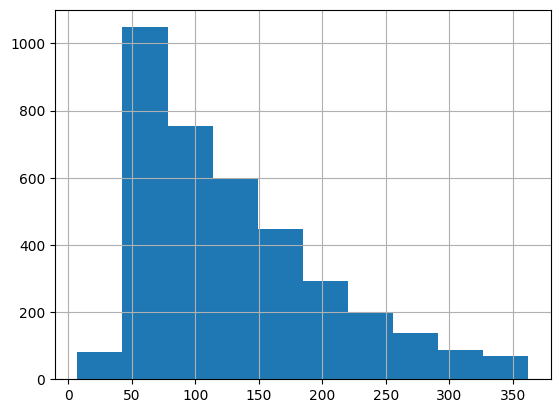

In [19]:
df_sin_outliers["tiempo_espera"].hist()

In [20]:
df_sin_outliers["tiempo_espera"].describe()

count    3718.000000
mean      130.454737
std        73.706344
min         7.222000
25%        70.629500
50%       111.819000
75%       172.156250
max       362.248000
Name: tiempo_espera, dtype: float64

In [21]:
len(df_sin_outliers)

3718

In [22]:
df_sin_outliers

,index,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,llegada_lon,llegada_lat,salida_lon,salida_lat,...,holding_point_Y3,holding_point_Z1,holding_point_Z2,holding_point_Z3,holding_point_Z4,holding_point_Z6,runway_14L/32R,runway_14R/32L,runway_18L/36R,runway_18R/36L
0,1176,4cae92,2024-12-07 23:55:17.776,2024-12-07 23:57:08.891,2024-12-07 23:57:09.599,111.823,-3.576248,40.491508,-3.574645,40.497735,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2506,aace63,2024-12-07 23:48:35.885,2024-12-07 23:50:02.452,2024-12-07 23:50:03.161,87.276,-3.572617,40.491840,-3.574646,40.497265,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,3195,346310,2024-12-07 23:44:29.668,2024-12-07 23:47:32.440,2024-12-07 23:47:33.248,183.580,-3.576248,40.491508,-3.574661,40.498318,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1323,346057,2024-12-07 23:40:44.612,2024-12-07 23:44:31.084,2024-12-07 23:44:31.284,226.672,-3.572617,40.491835,-3.574646,40.498306,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,771,346456,2024-12-07 23:31:52.062,2024-12-07 23:33:19.151,2024-12-07 23:33:19.353,87.291,-3.572632,40.491835,-3.574631,40.497631,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3970,1362,4cada6,2024-12-01 04:58:11.239,2024-12-01 05:00:55.900,2024-12-01 05:00:56.920,165.681,-3.576456,40.491742,-3.574645,40.498247,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3971,3901,34134e,2024-12-01 04:18:23.081,2024-12-01 04:20:28.852,2024-12-01 04:20:29.259,126.178,-3.576599,40.492481,-3.574645,40.498515,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3972,1689,896614,2024-12-01 02:56:52.255,2024-12-01 02:59:23.321,2024-12-01 02:59:25.243,152.988,-3.576237,40.491497,-3.574630,40.495547,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3973,2354,347604,2024-12-01 00:49:59.888,2024-12-01 00:50:51.492,2024-12-01 00:50:51.998,52.110,-3.576221,40.491532,-3.574630,40.498434,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [23]:
df_sin_outliers = df_sin_outliers.sort_values(by = "despegue")
df_sin_outliers

,index,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,llegada_lon,llegada_lat,salida_lon,salida_lat,...,holding_point_Y3,holding_point_Z1,holding_point_Z2,holding_point_Z3,holding_point_Z4,holding_point_Z6,runway_14L/32R,runway_14R/32L,runway_18L/36R,runway_18R/36L
3974,1967,aac33e,2024-12-01 00:36:58.063,2024-12-01 00:39:47.434,2024-12-01 00:39:48.750,170.687,-3.572554,40.490578,-3.574645,40.497735,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3973,2354,347604,2024-12-01 00:49:59.888,2024-12-01 00:50:51.492,2024-12-01 00:50:51.998,52.110,-3.576221,40.491532,-3.574630,40.498434,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3972,1689,896614,2024-12-01 02:56:52.255,2024-12-01 02:59:23.321,2024-12-01 02:59:25.243,152.988,-3.576237,40.491497,-3.574630,40.495547,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3971,3901,34134e,2024-12-01 04:18:23.081,2024-12-01 04:20:28.852,2024-12-01 04:20:29.259,126.178,-3.576599,40.492481,-3.574645,40.498515,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3970,1362,4cada6,2024-12-01 04:58:11.239,2024-12-01 05:00:55.900,2024-12-01 05:00:56.920,165.681,-3.576456,40.491742,-3.574645,40.498247,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,771,346456,2024-12-07 23:31:52.062,2024-12-07 23:33:19.151,2024-12-07 23:33:19.353,87.291,-3.572632,40.491835,-3.574631,40.497631,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1323,346057,2024-12-07 23:40:44.612,2024-12-07 23:44:31.084,2024-12-07 23:44:31.284,226.672,-3.572617,40.491835,-3.574646,40.498306,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,3195,346310,2024-12-07 23:44:29.668,2024-12-07 23:47:32.440,2024-12-07 23:47:33.248,183.580,-3.576248,40.491508,-3.574661,40.498318,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2506,aace63,2024-12-07 23:48:35.885,2024-12-07 23:50:02.452,2024-12-07 23:50:03.161,87.276,-3.572617,40.491840,-3.574646,40.497265,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [24]:
def saca_puntos_espera(llegada_punto_referencia,holding_referencia,indice,llegada_punto,salida_punto,holding_point):
    if (llegada_punto_referencia >= llegada_punto) and  (salida_punto >= llegada_punto_referencia):
        print("llegada_punto_referencia",llegada_punto_referencia)
        print("llegada_punto",llegada_punto)
        print("salida_punto",salida_punto)
        print("holding_referencia",holding_referencia)
        print("holding_point",holding_point)
        if holding_referencia !=holding_point:
            return indice,holding_point
        else:
            return indice,None
    else:
        return indice,None 
    

In [25]:
df_sin_outliers = df_sin_outliers.reset_index(drop =True)
df_sin_outliers

,index,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,llegada_lon,llegada_lat,salida_lon,salida_lat,...,holding_point_Y3,holding_point_Z1,holding_point_Z2,holding_point_Z3,holding_point_Z4,holding_point_Z6,runway_14L/32R,runway_14R/32L,runway_18L/36R,runway_18R/36L
0,1967,aac33e,2024-12-01 00:36:58.063,2024-12-01 00:39:47.434,2024-12-01 00:39:48.750,170.687,-3.572554,40.490578,-3.574645,40.497735,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2354,347604,2024-12-01 00:49:59.888,2024-12-01 00:50:51.492,2024-12-01 00:50:51.998,52.110,-3.576221,40.491532,-3.574630,40.498434,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1689,896614,2024-12-01 02:56:52.255,2024-12-01 02:59:23.321,2024-12-01 02:59:25.243,152.988,-3.576237,40.491497,-3.574630,40.495547,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,3901,34134e,2024-12-01 04:18:23.081,2024-12-01 04:20:28.852,2024-12-01 04:20:29.259,126.178,-3.576599,40.492481,-3.574645,40.498515,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,1362,4cada6,2024-12-01 04:58:11.239,2024-12-01 05:00:55.900,2024-12-01 05:00:56.920,165.681,-3.576456,40.491742,-3.574645,40.498247,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3713,771,346456,2024-12-07 23:31:52.062,2024-12-07 23:33:19.151,2024-12-07 23:33:19.353,87.291,-3.572632,40.491835,-3.574631,40.497631,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3714,1323,346057,2024-12-07 23:40:44.612,2024-12-07 23:44:31.084,2024-12-07 23:44:31.284,226.672,-3.572617,40.491835,-3.574646,40.498306,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3715,3195,346310,2024-12-07 23:44:29.668,2024-12-07 23:47:32.440,2024-12-07 23:47:33.248,183.580,-3.576248,40.491508,-3.574661,40.498318,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3716,2506,aace63,2024-12-07 23:48:35.885,2024-12-07 23:50:02.452,2024-12-07 23:50:03.161,87.276,-3.572617,40.491840,-3.574646,40.497265,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [26]:
df_sin_outliers.loc[1,["llegada_punto","salida_punto","holding_point"]]

llegada_punto    2024-12-01 00:49:59.888000
salida_punto     2024-12-01 00:50:51.492000
holding_point                            Z2
Name: 1, dtype: object

In [27]:
df_sin_outliers.loc[2,["llegada_punto","salida_punto","holding_point"]]

llegada_punto    2024-12-01 02:56:52.255000
salida_punto     2024-12-01 02:59:23.321000
holding_point                            Z2
Name: 2, dtype: object

In [28]:
df_sin_outliers.loc[2,["llegada_punto"]].values[0]

Timestamp('2024-12-01 02:56:52.255000')

In [29]:
lista = []
for i, (index, row) in enumerate(df_sin_outliers.iterrows()):
    if (i -1)>=0:
        llegada_punto_referencia,salida_punto_referencia,despegue,holding_referencia = row["llegada_punto"],row["salida_punto"],row["despegue"],row["holding_point"]
        resultados= df_sin_outliers.iloc[:i-1].apply(lambda row: saca_puntos_espera(llegada_punto_referencia,holding_referencia,i,row["llegada_punto"],row["salida_punto"],row["holding_point"]),axis=1)
        lista.append(resultados)
    

llegada_punto_referencia 2024-12-01 06:20:47.448000
llegada_punto 2024-12-01 06:20:18.236000
salida_punto 2024-12-01 06:21:21.848000
holding_referencia Z2
holding_point Z2
llegada_punto_referencia 2024-12-01 06:21:14.472000
llegada_punto 2024-12-01 06:20:18.236000
salida_punto 2024-12-01 06:21:21.848000
holding_referencia Z4
holding_point Z2
llegada_punto_referencia 2024-12-01 06:21:14.472000
llegada_punto 2024-12-01 06:20:55.314000
salida_punto 2024-12-01 06:21:47.355000
holding_referencia Z4
holding_point Y1
llegada_punto_referencia 2024-12-01 06:21:14.472000
llegada_punto 2024-12-01 06:20:47.448000
salida_punto 2024-12-01 06:23:07.735000
holding_referencia Z4
holding_point Z2
llegada_punto_referencia 2024-12-01 06:26:45.349000
llegada_punto 2024-12-01 06:26:00.177000
salida_punto 2024-12-01 06:27:24.405000
holding_referencia Y1
holding_point Y1
llegada_punto_referencia 2024-12-01 06:28:13.174000
llegada_punto 2024-12-01 06:26:36.014000
salida_punto 2024-12-01 06:28:23.387000
holding

In [43]:
lista[300]

0      (301, None)
1      (301, None)
2      (301, None)
3      (301, None)
4      (301, None)
          ...     
295    (301, None)
296    (301, None)
297    (301, None)
298    (301, None)
299    (301, None)
Length: 300, dtype: object

In [30]:
lista_filtrada = [
    [(idx, val) for idx, val in arr if val is not None]
    for arr in lista[1:] if any(val is not None for _, val in arr)
]


In [98]:
df_sin_outliers

,index,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,llegada_lon,llegada_lat,salida_lon,salida_lat,...,hora_despegue,aircraft_type_Heavy (larger than 136000 kg),aircraft_type_High vortex aircraft,aircraft_type_Light (less than 7000 kg),aircraft_type_Medium 1 (between 7000 kg and 34000 kg),aircraft_type_Medium 2 (between 34000 kg to 136000 kg),runway_14L/32R,runway_14R/32L,runway_18L/36R,runway_18R/36L
0,1967,aac33e,2024-12-01 00:36:58.063,2024-12-01 00:39:47.434,2024-12-01 00:39:48.750,170.687,-3.572554,40.490578,-3.574645,40.497735,...,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2354,347604,2024-12-01 00:49:59.888,2024-12-01 00:50:51.492,2024-12-01 00:50:51.998,52.110,-3.576221,40.491532,-3.574630,40.498434,...,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1689,896614,2024-12-01 02:56:52.255,2024-12-01 02:59:23.321,2024-12-01 02:59:25.243,152.988,-3.576237,40.491497,-3.574630,40.495547,...,2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,3901,34134e,2024-12-01 04:18:23.081,2024-12-01 04:20:28.852,2024-12-01 04:20:29.259,126.178,-3.576599,40.492481,-3.574645,40.498515,...,4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,1362,4cada6,2024-12-01 04:58:11.239,2024-12-01 05:00:55.900,2024-12-01 05:00:56.920,165.681,-3.576456,40.491742,-3.574645,40.498247,...,5,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3713,771,346456,2024-12-07 23:31:52.062,2024-12-07 23:33:19.151,2024-12-07 23:33:19.353,87.291,-3.572632,40.491835,-3.574631,40.497631,...,23,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3714,1323,346057,2024-12-07 23:40:44.612,2024-12-07 23:44:31.084,2024-12-07 23:44:31.284,226.672,-3.572617,40.491835,-3.574646,40.498306,...,23,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3715,3195,346310,2024-12-07 23:44:29.668,2024-12-07 23:47:32.440,2024-12-07 23:47:33.248,183.580,-3.576248,40.491508,-3.574661,40.498318,...,23,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3716,2506,aace63,2024-12-07 23:48:35.885,2024-12-07 23:50:02.452,2024-12-07 23:50:03.161,87.276,-3.572617,40.491840,-3.574646,40.497265,...,23,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [31]:
for lista_i in lista_filtrada:
    print(lista_i)
#lista_filtrada

[(33, 'Z2'), (33, 'Y1'), (33, 'Z2')]
[(39, 'Z4')]
[(40, 'Y1')]
[(41, 'Z4')]
[(43, 'Z4')]
[(44, 'Z4')]
[(55, 'Y1')]
[(58, 'Y1')]
[(60, 'Z4')]
[(61, 'Y2')]
[(64, 'Y2'), (64, 'Z2'), (64, 'Z2')]
[(67, 'Z4')]
[(90, 'Z3')]
[(92, 'Z1')]
[(96, 'Z3')]
[(106, 'Z2')]
[(116, 'Y1')]
[(121, 'Z2')]
[(122, 'Y1')]
[(125, 'Y1')]
[(150, 'Y1'), (150, 'Z2')]
[(153, 'Y1')]
[(167, 'Y1')]
[(172, 'Y1')]
[(176, 'Z4')]
[(182, 'Y1')]
[(183, 'Z4')]
[(184, 'Y2'), (184, 'Z4')]
[(185, 'Z4'), (185, 'Z2')]
[(186, 'Z4'), (186, 'Z2'), (186, 'Y1')]
[(189, 'Y1'), (189, 'Y1')]
[(191, 'Y1'), (191, 'Z3')]
[(193, 'Z4')]
[(195, 'Y1')]
[(197, 'Y2')]
[(200, 'Y1')]
[(202, 'Z2')]
[(205, 'Z4'), (205, 'Z4')]
[(206, 'Y1')]
[(215, 'Z4')]
[(217, 'Z2')]
[(222, 'Y1')]
[(226, 'Z3')]
[(227, 'Z1')]
[(236, 'Y1')]
[(240, 'Z3')]
[(247, 'Z3')]
[(261, 'Z2')]
[(273, 'Y1')]
[(294, 'Z2')]
[(296, 'Y2')]
[(298, 'Z4')]
[(300, 'Y1')]
[(302, 'Y1')]
[(308, 'Z4')]
[(315, 'Z2')]
[(317, 'Y1'), (317, 'Z3')]
[(320, 'Z2'), (320, 'Y1')]
[(322, 'Z2'), (322, 'Y1')

In [32]:
mapping = {
    'Y1': 'Y',
    'Y2': 'Y',
    'Y3': 'Y',
    'Z1': 'Z',
    'Z2': 'Z',
    'Z3': 'Z',
    'Z4': 'Z',
    'Z6': 'Z',
    'K1': 'K',
    'K2': 'K',
    'K3': 'K',
    'KA6': 'KA',
    'KA8': 'KA',
    'LA': 'L',
    'LB': 'L',
    'LC': 'L',
    'LE': 'L',
    'LF': 'L',
    'L1': 'L'
}

In [33]:
from sklearn.cluster import DBSCAN
import numpy as np

# Coordenadas extraídas del GeoJSON
coords = np.array([
    [-3.573093114831562, 40.490653160130186],  # Z1
    [-3.537524367869231, 40.472076292010001],  # KA6
    [-3.536653485337274, 40.466622566754253],  # KA8
    [-3.558959606954449, 40.494122669084419],  # K3
    [-3.559326044131887, 40.4945961819448],    # K2
    [-3.560411408421098, 40.495554592925956],  # K1
    [-3.560656492186808, 40.499431092287409],  # Y1
    [-3.560645785166937, 40.500298406173002],  # Y2
    [-3.560660061193443, 40.501183565039504],  # Y3
    [-3.560800449906033, 40.533391949745102],  # Y7
    [-3.576129307304151, 40.495184843931881],  # Z6
    [-3.576034129003182, 40.492555539298088],  # Z4
    [-3.575903257941006, 40.491865496230126],  # Z2
    [-3.57319305240692, 40.491819096186241],   # Z3
    [-3.572566658955927, 40.479721203031424],  # LF
    [-3.57652786733783, 40.483565816902733],   # L1
    [-3.577181028787666, 40.484251101106899],  # LA
    [-3.577553413710587, 40.484873329796898],  # LB
    [-3.575750378154376, 40.486690643924192],  # LC
    [-3.575150753600524, 40.486522892072891],  # LD
    [-3.574915186586964, 40.485580625293494]   # LE
])

# Convertir a metros
lat_mean = np.deg2rad(40.5)  # Latitud media en radianes
meters_per_lat = 111000
meters_per_lon = 84000  # 111000 * cos(40.5°)
coords_meters = coords * np.array([meters_per_lon, meters_per_lat])

# Aplicar DBSCAN
db = DBSCAN(eps=250, min_samples=1, metric='euclidean').fit(coords_meters)
labels = db.labels_

# Lista de puntos
points = ['Z1', 'KA6', 'KA8', 'K3', 'K2', 'K1', 'Y1', 'Y2', 'Y3', 'Y7', 'Z6', 'Z4', 'Z2', 'Z3', 'LF', 'L1', 'LA', 'LB', 'LC', 'LD', 'LE']

# Crear diccionario
mapping = {points[i]: f'Cluster_{labels[i]}' for i in range(len(points))}
print(mapping)

{'Z1': 'Cluster_0', 'KA6': 'Cluster_1', 'KA8': 'Cluster_2', 'K3': 'Cluster_3', 'K2': 'Cluster_3', 'K1': 'Cluster_3', 'Y1': 'Cluster_4', 'Y2': 'Cluster_4', 'Y3': 'Cluster_4', 'Y7': 'Cluster_5', 'Z6': 'Cluster_6', 'Z4': 'Cluster_0', 'Z2': 'Cluster_0', 'Z3': 'Cluster_0', 'LF': 'Cluster_7', 'L1': 'Cluster_8', 'LA': 'Cluster_8', 'LB': 'Cluster_8', 'LC': 'Cluster_8', 'LD': 'Cluster_8', 'LE': 'Cluster_8'}


In [34]:
mapping

{'Z1': 'Cluster_0',
 'KA6': 'Cluster_1',
 'KA8': 'Cluster_2',
 'K3': 'Cluster_3',
 'K2': 'Cluster_3',
 'K1': 'Cluster_3',
 'Y1': 'Cluster_4',
 'Y2': 'Cluster_4',
 'Y3': 'Cluster_4',
 'Y7': 'Cluster_5',
 'Z6': 'Cluster_6',
 'Z4': 'Cluster_0',
 'Z2': 'Cluster_0',
 'Z3': 'Cluster_0',
 'LF': 'Cluster_7',
 'L1': 'Cluster_8',
 'LA': 'Cluster_8',
 'LB': 'Cluster_8',
 'LC': 'Cluster_8',
 'LD': 'Cluster_8',
 'LE': 'Cluster_8'}

In [35]:
lista_filtrada

[[(33, 'Z2'), (33, 'Y1'), (33, 'Z2')],
 [(39, 'Z4')],
 [(40, 'Y1')],
 [(41, 'Z4')],
 [(43, 'Z4')],
 [(44, 'Z4')],
 [(55, 'Y1')],
 [(58, 'Y1')],
 [(60, 'Z4')],
 [(61, 'Y2')],
 [(64, 'Y2'), (64, 'Z2'), (64, 'Z2')],
 [(67, 'Z4')],
 [(90, 'Z3')],
 [(92, 'Z1')],
 [(96, 'Z3')],
 [(106, 'Z2')],
 [(116, 'Y1')],
 [(121, 'Z2')],
 [(122, 'Y1')],
 [(125, 'Y1')],
 [(150, 'Y1'), (150, 'Z2')],
 [(153, 'Y1')],
 [(167, 'Y1')],
 [(172, 'Y1')],
 [(176, 'Z4')],
 [(182, 'Y1')],
 [(183, 'Z4')],
 [(184, 'Y2'), (184, 'Z4')],
 [(185, 'Z4'), (185, 'Z2')],
 [(186, 'Z4'), (186, 'Z2'), (186, 'Y1')],
 [(189, 'Y1'), (189, 'Y1')],
 [(191, 'Y1'), (191, 'Z3')],
 [(193, 'Z4')],
 [(195, 'Y1')],
 [(197, 'Y2')],
 [(200, 'Y1')],
 [(202, 'Z2')],
 [(205, 'Z4'), (205, 'Z4')],
 [(206, 'Y1')],
 [(215, 'Z4')],
 [(217, 'Z2')],
 [(222, 'Y1')],
 [(226, 'Z3')],
 [(227, 'Z1')],
 [(236, 'Y1')],
 [(240, 'Z3')],
 [(247, 'Z3')],
 [(261, 'Z2')],
 [(273, 'Y1')],
 [(294, 'Z2')],
 [(296, 'Y2')],
 [(298, 'Z4')],
 [(300, 'Y1')],
 [(302, 'Y1')],

In [103]:
print(df_sin_outliers)

      index    ICAO           llegada_punto            salida_punto  \
0      1967  aac33e 2024-12-01 00:36:58.063 2024-12-01 00:39:47.434   
1      2354  347604 2024-12-01 00:49:59.888 2024-12-01 00:50:51.492   
2      1689  896614 2024-12-01 02:56:52.255 2024-12-01 02:59:23.321   
3      3901  34134e 2024-12-01 04:18:23.081 2024-12-01 04:20:28.852   
4      1362  4cada6 2024-12-01 04:58:11.239 2024-12-01 05:00:55.900   
...     ...     ...                     ...                     ...   
3713    771  346456 2024-12-07 23:31:52.062 2024-12-07 23:33:19.151   
3714   1323  346057 2024-12-07 23:40:44.612 2024-12-07 23:44:31.084   
3715   3195  346310 2024-12-07 23:44:29.668 2024-12-07 23:47:32.440   
3716   2506  aace63 2024-12-07 23:48:35.885 2024-12-07 23:50:02.452   
3717   1176  4cae92 2024-12-07 23:55:17.776 2024-12-07 23:57:08.891   

                    despegue  tiempo_espera  llegada_lon  llegada_lat  \
0    2024-12-01 00:39:48.750        170.687    -3.572554    40.490578   
1

In [36]:
# Procesar lista_filtrada para contar holding points únicos por índice
from collections import defaultdict
holding_points_por_indice = defaultdict(set)
for sublista in lista_filtrada:
    indice = sublista[0][0]  # El índice es el mismo en toda la sublista
    for _, hp in sublista:
        holding_points_por_indice[indice].add(hp)

# Crear un diccionario con la cantidad de holding points únicos por índice
cantidad_hp_por_indice = {indice: len(hps) for indice, hps in holding_points_por_indice.items()}

# Añadir la columna 'pistas_ocupadas' al DataFrame
# Suponiendo que df_sin_outliers ya está definido (asegúrate de tenerlo cargado)
import pandas as pd
# Ejemplo: si no lo tienes cargado, descomenta y ajusta esto con tus datos reales
# df_sin_outliers = pd.read_csv('tu_archivo.csv')  

df_sin_outliers['pistas_ocupadas'] = df_sin_outliers['index'].map(cantidad_hp_por_indice).fillna(0).astype(int)

# Mostrar las primeras filas para verificar
print(df_sin_outliers[['index', 'ICAO', 'llegada_punto', 'salida_punto', 'pistas_ocupadas']].head())

   index    ICAO           llegada_punto            salida_punto  \
0   1967  aac33e 2024-12-01 00:36:58.063 2024-12-01 00:39:47.434   
1   2354  347604 2024-12-01 00:49:59.888 2024-12-01 00:50:51.492   
2   1689  896614 2024-12-01 02:56:52.255 2024-12-01 02:59:23.321   
3   3901  34134e 2024-12-01 04:18:23.081 2024-12-01 04:20:28.852   
4   1362  4cada6 2024-12-01 04:58:11.239 2024-12-01 05:00:55.900   

   pistas_ocupadas  
0                0  
1                0  
2                1  
3                0  
4                0  


In [37]:
df_sin_outliers["pistas_ocupadas"].value_counts()

pistas_ocupadas
0    3058
1     521
2     122
3      16
4       1
Name: count, dtype: int64

In [38]:
df_sin_outliers = df_sin_outliers.drop(columns="holding_point")

In [39]:
df_sin_outliers["tiempo_espera"]

0       170.687
1        52.110
2       152.988
3       126.178
4       165.681
         ...   
3713     87.291
3714    226.672
3715    183.580
3716     87.276
3717    111.823
Name: tiempo_espera, Length: 3718, dtype: float64

In [50]:
df_sin_outliers.dtypes

llegada_punto                                             datetime64[ns]
salida_punto                                              datetime64[ns]
despegue                                                  datetime64[ns]
tiempo_espera                                                    float64
llegada_lon                                                      float64
llegada_lat                                                      float64
salida_lon                                                       float64
salida_lat                                                       float64
parado                                                              bool
fecha_despegue                                            datetime64[ns]
hora_despegue                                                      int64
aircraft_type_Heavy (larger than 136000 kg)                      float64
aircraft_type_High vortex aircraft                               float64
aircraft_type_Light (less than 7000 kg)            

In [58]:
df_sin_outliers

,tiempo_espera,llegada_lon,llegada_lat,salida_lon,salida_lat,parado,hora_despegue,aircraft_type_Heavy (larger than 136000 kg),aircraft_type_High vortex aircraft,aircraft_type_Light (less than 7000 kg),...,holding_point_Z1,holding_point_Z2,holding_point_Z3,holding_point_Z4,holding_point_Z6,runway_14L/32R,runway_14R/32L,runway_18L/36R,runway_18R/36L,pistas_ocupadas
0,170.687,-3.572554,40.490578,-3.574645,40.497735,True,0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
1,52.110,-3.576221,40.491532,-3.574630,40.498434,False,0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
2,152.988,-3.576237,40.491497,-3.574630,40.495547,False,2,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
3,126.178,-3.576599,40.492481,-3.574645,40.498515,False,4,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
4,165.681,-3.576456,40.491742,-3.574645,40.498247,True,5,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3713,87.291,-3.572632,40.491835,-3.574631,40.497631,False,23,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0
3714,226.672,-3.572617,40.491835,-3.574646,40.498306,False,23,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0
3715,183.580,-3.576248,40.491508,-3.574661,40.498318,False,23,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
3716,87.276,-3.572617,40.491840,-3.574646,40.497265,False,23,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1


In [59]:
df_sin_outliers = df_sin_outliers.drop(columns = ["llegada_punto","salida_punto","despegue","fecha_despegue"])
df_sin_outliers = df_sin_outliers.drop("pistas_ocupadas")

KeyError: "['llegada_punto', 'salida_punto', 'despegue', 'fecha_despegue'] not found in axis"

In [61]:
df_sin_outliers = df_sin_outliers.drop(columns = "pistas_ocupadas")

In [62]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
X = df_sin_outliers.drop(columns=["tiempo_espera"])
y = df_sin_outliers["tiempo_espera"]

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizar los datos de entrada
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Construcción del modelo
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)  # Capa de salida sin activación para regresión
])

# Compilar el modelo
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=200, batch_size=16, validation_data=(X_test, y_test))

# Evaluar el modelo
test_loss, test_mae = model.evaluate(X_test, y_test)
print(f"Error absoluto medio en test: {test_mae:.2f}")


Epoch 1/200


/Users/hamzatriki/3ºProyectoDeDatos2/PD2/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 14427.3896 - mae: 94.4308 - val_loss: 2401.6052 - val_mae: 38.5336
Epoch 2/200
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 710us/step - loss: 2528.6587 - mae: 38.7734 - val_loss: 2252.1392 - val_mae: 37.3474
Epoch 3/200
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 732us/step - loss: 2505.0471 - mae: 38.7882 - val_loss: 2332.7480 - val_mae: 36.4443
Epoch 4/200
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 728us/step - loss: 2348.2544 - mae: 37.0149 - val_loss: 2246.2561 - val_mae: 36.8923
Epoch 5/200
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 659us/step - loss: 2471.0625 - mae: 38.3530 - val_loss: 2247.0325 - val_mae: 37.7770
Epoch 6/200
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 691us/step - loss: 2387.2266 - mae: 38.1734 - val_loss: 2283.6567 - val_mae: 36.6695
Epoch 7/200
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 672us/step - loss: 2398.4480 - mae: 37.7514 - val_loss: 2270.4333 - val_mae: 36.2894
Epoch 8/200
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 671us/step - loss: 2223.5864 - mae: 36.9766 - val_loss: 2220.0518 

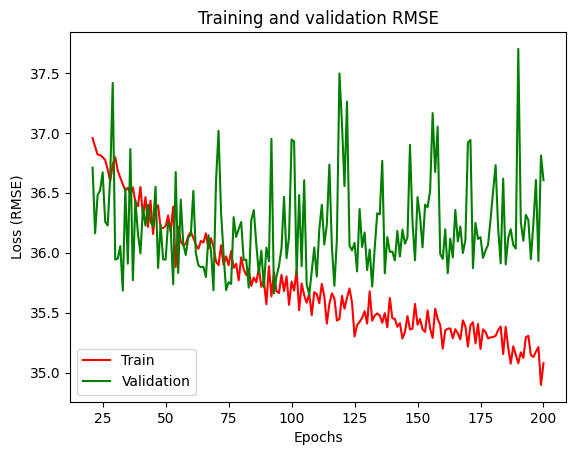

In [53]:
import matplotlib.pyplot as plt

loss = history.history['mae']
val_loss = history.history['val_mae']

epochs = range(1, len(loss) + 1)

plt.plot(epochs[20:], loss[20:], 'r', label='Train')
plt.plot(epochs[20:], val_loss[20:], 'g', label='Validation')

plt.title('Training and validation RMSE')
plt.xlabel('Epochs')
plt.ylabel('Loss (RMSE)')
plt.legend()

plt.show()

In [13]:
df_lista = []
for indice, fila in df_encoded_sorted.iterrows():
    if indice < len(df_encoded_sorted) - 1:  # Verificar que no sea el último índice
        tiempo_referencia = fila["despegue"]
        
        # Seleccionar solo las filas a partir del índice
        tiempos= df_encoded_sorted.iloc[indice:].apply(
            lambda row: calcular_tiempo_relativo(tiempo_referencia, row["despegue"]), axis=1)
        
        # Filtrar el DataFrame en función de la columna 'ventana'
        ##df_filter = df_encoded_sorted[(df_encoded_sorted["ventana"] <= 1800)]
    
        tiempos = tiempos[tiempos <=1800]
   
        df_concat = pd.concat([df_encoded_sorted.iloc[indice: indice + len(tiempos)],tiempos],axis =1)
        df_lista.append(df_concat)


In [20]:
df_lista[16]

,index,ICAO,ultimo_parado,despegue,tiempo_espera,lat,lon,fecha_despegue,hora_despegue,aircraft_type_Heavy (larger than 136000 kg),...,holding_point_Z2,holding_point_Z3,holding_point_Z4,holding_point_Z6,runway_14L/32R,runway_14R/32L,runway_18L/36R,runway_18R/36L,runway_nan,0
16,1294,4d22b1,2024-12-07 19:23:06.400,2024-12-07 19:25:05.533,119.133,40.505672,-3.559243,2024-12-07,19,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.000
17,378,346082,2024-12-07 19:22:52.903,2024-12-07 19:24:28.367,95.464,40.495846,-3.574646,2024-12-07,19,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,37.166
18,1049,3472c9,2024-12-07 19:21:22.609,2024-12-07 19:22:57.972,95.363,40.497448,-3.574677,2024-12-07,19,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,127.561
19,918,3451da,2024-12-07 19:19:28.541,2024-12-07 19:21:34.394,125.853,40.497723,-3.574646,2024-12-07,19,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,211.139
20,214,347648,2024-12-07 19:18:11.059,2024-12-07 19:19:54.912,103.853,40.494358,-3.574631,2024-12-07,19,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,310.621
21,604,3451d9,2024-12-07 19:03:19.564,2024-12-07 19:04:42.408,82.844,40.499222,-3.574661,2024-12-07,19,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1223.125
22,467,345698,2024-12-07 18:58:30.030,2024-12-07 19:02:17.756,227.726,40.499474,-3.574661,2024-12-07,19,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1367.777
23,649,344216,2024-12-07 18:57:21.751,2024-12-07 19:00:47.118,205.367,40.499817,-3.574692,2024-12-07,19,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1458.415


In [244]:
for i, df in enumerate(df_lista):
    df.to_csv(f"/Users/hamzatriki/3ºProyectoDeDatos2/PD2/data/modelado/dataframe_{i}.csv", index=False)